# Kitten tomography

Outline:

* Simple model (Dakna) - fidelity with cat state - QuTiP
* More realistic model (BS + photon click, losses, sum of Gaussians) - QuTiP
* or, Even more realistic model (if I have time) (temporal correlations + mode function)
* Build homodyne samples (optional: include phase noise, electronic noise, dark counts)
* Tomography (MaxLik)
* DM -> Wigner
* Study:
  * fidelity with cat
  * vary squeezing, BS ratio, loss
  * vary number of samples, phases, interation steps

In this guided exercise (or mini-project), you will emulate a not unusual workflow in experimental science: Before doing a challenging experiment, perhaps using new methods for the first time, it is valuable to have a rough idea whether doing the experiment is feasible at all. This can _sometimes_ be achieved by doing a simulation of the experiment and the anticipated data analysis, although this requires a fairly good understanding of the physics involved. 

As an example, this is a workflow we followed in our 2025 paper on [Quantum learning advantage](https://www.science.org/doi/abs/10.1126/science.adv2560). This was a challenging experiment that took several months to build, and with long measurement runs. The underlying physics was simple and well understood, but the data analysis would be harder than most other experiments we had done. This lent it self perfectly to do a pre-simulation of the experiment, where we could develop and test our data analysis on simulated measurements.

That experiment is too hard to understand and simulate in just a day, so instead you should try to emulate a much simpler experiment: The [generation of a _Schrödinger kitten state_](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=2OC-ZjEAAAAJ&citation_for_view=2OC-ZjEAAAAJ:u5HHmVD_uO8C) that I did during my PhD and which is described in detail in [my thesis](https://figshare.com/articles/thesis/Generation_of_single_photons_and_Schr_dinger_kitten_states_of_light/1328405?file=1939711). 

The objectives of this exercise are:
* Do a simple modeling with QuTiP of photon-subtraction from squeezed vacuum states and compare with true Schrödinger cat states.
* Simulate the results of homodyne measurements on this state.
* Implement quantum state tomography based on the Maximum Likelihood method.
* Visualise the results. Vary experimental parameters to understand the requirements for a successful demonstration. 

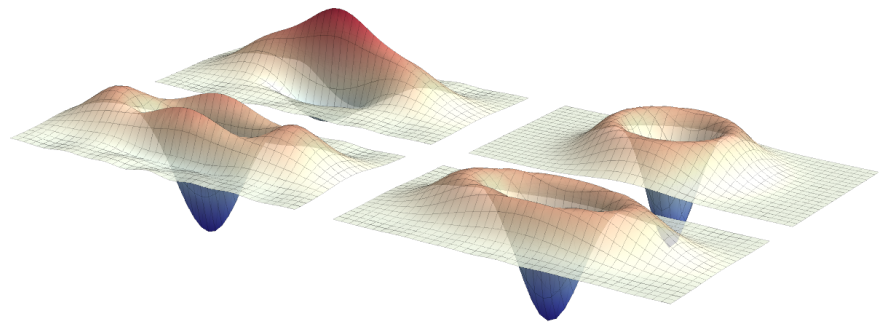

## Simple model of photon-subtracted squeezed vacuum states

Different kinds of quantum states have been called "Schrödinger cat states" based on their property of being a superposition of classically distinguishable states, like Schrödinger's superposition of a dead and a live cat. For qubits/spin systems, the GHZ state $(|00\ldots00\rangle + |11\ldots11\rangle)/\sqrt{2}$ is sometimes called a cat states. In continuous-variable quantum information, the name is used for superpositions of coherent states, $|\text{cat}_\pm\rangle = \mathcal{N}_\pm (|\alpha\rangle \pm |{-}\alpha\rangle)$, where $\mathcal{N}_\pm$ is a normalisation factor, and the + and - versions of the state are called the _even_ and _odd_ cat state, respectively. You can plot the photon number distribution of the two states to understand these names. 

[Dakna et al.](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.55.3184) realised that a good approximation for the continuous-variable cat states with small amplitudes (hence a "Schrödinger kitten") can be obtained by subtracting one or more photons from a squeezed vacuum state. The photon-subtracted squeezed vacuum state, PSSQV, is ideally given by $\mathcal{N}\hat{a}^m\hat{S}(r)|0\rangle$, where $r$ is the squeezing parameter, $m$ is the number of photons to subtract, and $\mathcal{n}$ is a normalisation factor (because the annihilation operator is non-unitary, so it doesn't preserve normalisation). For odd (even) $m$, this looks a bit like the odd (even) cat state. 

### Task 1: Compare the PSSQV and cat states

* Using QuTiP, calculate the PSSQV state defined above for different values of $r$ and $m$ and calculate the true odd and even cat states for different values of $\alpha$.
* Compare the states either visually, by plotting their Wigner functions (`qutip.plot_wigner`), and/or by calculating their fidelities, defined as $F(|\psi\rangle, |\phi\rangle) = |\langle\psi|\phi\rangle|^2$.  
  NOTE: To get this most common definition of the fidelity, you must square the value obtained by `qutip.fidelity`.
* You could for example try to recreate Figure 3.5 in my thesis, where for each $r$-value, the fidelity was optimised over varying $\alpha$ values.  
  NOTE: Doing this requires many evaluations of the PSSQV state. This will take several minutes. The `qutip.squeeze` operator can be a bottleneck here, and you might be able to significantly speed up the simulation by instead building the squeezed vacuum state vector manually by `qutip.Qobj([c0,c1,c2,...,c{N-1}])`, where the coefficients `ci` are given in eq. (2.20) of my thesis. You could profile these two different methods with `%timeit` and `%lprun`.
* Alternatively, you could do a contour plot over $r$ and $\alpha$.
* For the visual comparison, you could set up an `ipywidgets.interact` interface for varying the parameters. Include the Fock-space cutoff `N` to see the effect of cropping off too soon. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import h5py
import qutip as q
from tqdm.notebook import tqdm

def catstate(N, alpha, phase):# cat state builder
    psi = q.coherent(N, alpha) + np.exp(1j*phase) * q.coherent(N, -alpha)
    return psi.unit()


def pssqv(N, r, m): #squid of vaccum N is how many level you want , r si how hard you gonna squiz in x directin r high: o->0 m is how many operator you gonaa walk through
    psi = q.squeeze(N, r) * q.basis(N, 0)
    a = q.destroy(N)
    for _ in range(m):
        psi = a * psi
    return psi.unit()




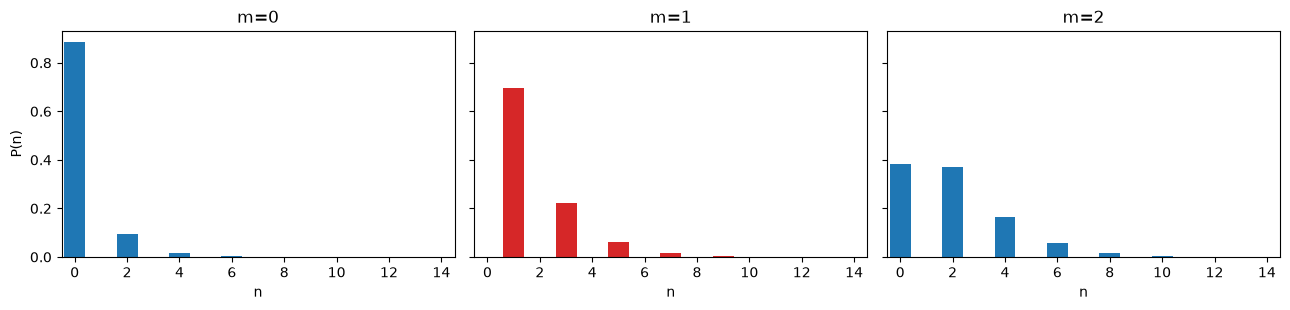

In [ ]:
N = 60
r_test = 0.5

#parity chechk
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, m in zip(axes, [0, 1, 2]):
    psi = pssqv(N, r_test, m)
    pn = np.abs(psi.full().ravel())**2
    ax.bar(range(N), pn, color=['C0' if n % 2 == 0 else 'C3' for n in range(N)])
    ax.set_xlim(-0.5, 14.5)
    ax.set_title(f"m={m}")
    ax.set_xlabel("n")
axes[0].set_ylabel("P(n)")
plt.tight_layout()

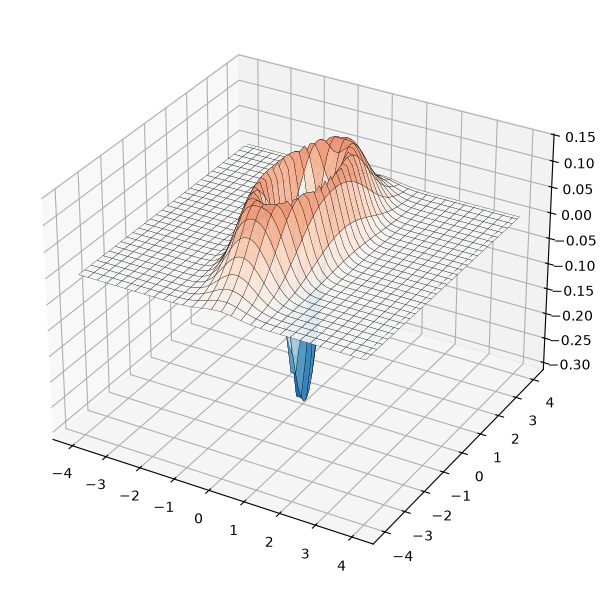

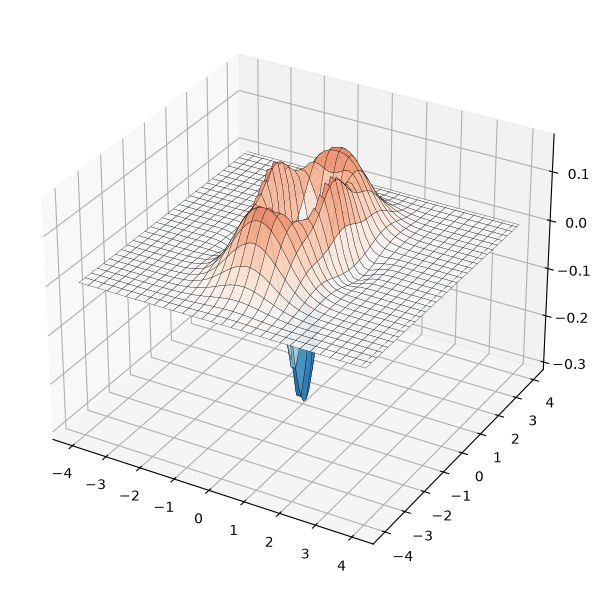

In [51]:
def plot_wigner_3d(psi, lim=4, npts=60): # plot wigner or else
    xvec = np.linspace(-lim, lim, npts)
    W = q.wigner(psi, xvec, xvec)
    X, Y = np.meshgrid(xvec, xvec)
    v = np.abs(W).max() or 1e-10

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(X, Y, W, cmap='RdBu_r', vmin=-v, vmax=v,
                    edgecolor='k', linewidth=0.2, alpha=0.9)
    plt.tight_layout()
    plt.show()


plot_wigner_3d(pssqv(60, 0.5, 1))
plot_wigner_3d(catstate(60, 1j*1.18, np.pi))

α_opt = 1.269,  F = 0.9840


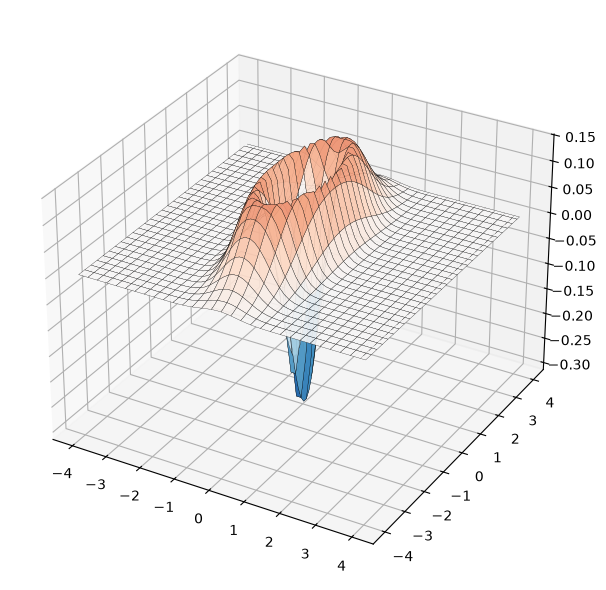

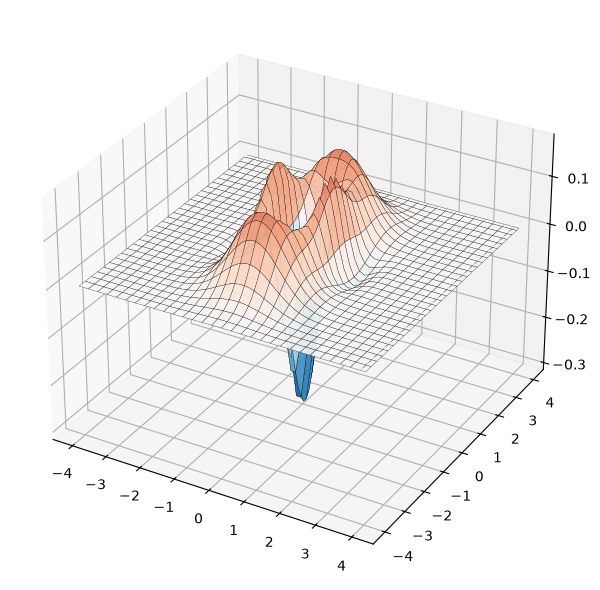

In [52]:
def best_cat(N, r, m, alphas=np.linspace(0.05, 2.5, 200)):
    ps = pssqv(N, r, m)
    phase = np.pi if m % 2 else 0.0
    cats = [catstate(N, 1j*a, phase) for a in alphas]
    F = np.array([abs(ps.overlap(c))**2 for c in cats])
    i = F.argmax()
    return cats[i], alphas[i], F[i]


def fidelity(psi1, psi2):
    return abs(psi1.overlap(psi2))**2


N, r, m = 100, 0.5, 1
ps = pssqv(N, r, m)
cat, a_opt, F = best_cat(N, r, m)
print(f"α_opt = {a_opt:.3f},  F = {F:.4f}")

plot_wigner_3d(ps) #squeeze pulse
plot_wigner_3d(cat) #similarlist one

### Task 2: A slightly more realistic experimental model

The photon subtraction operation can in principle be implemented on a propagating light mode through interaction with a two-level system, but this is experimentally demanding. Dakna et al. suggested this much simpler idea:

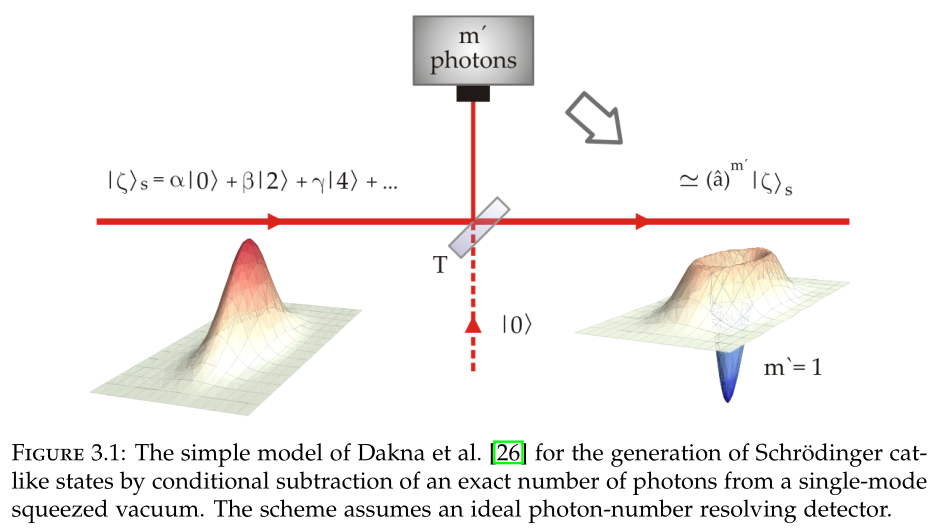

When $m$ photons are detected in the reflected path, those $m$ photons must be missing from the transmission – they have been subtracted. 

In practice, the ideal photon-number-resolving detector assumed here does not exist. Standard photon counters give a signal (a "click) when seeing one or more photons, i.e. it can only discriminate between $m=0$ and $m>0$. For a small reflection (high $T$) of the beamsplitter, very few photons will be reflected, so with high probability a click can be attributed to a single photon detection, thereby implementing the $m=1$ subtraction.

This binary "on/off" measurement is mathematically described as a POVM with elements $\hat\Pi_\text{off} = |0\rangle\langle0|$ (projection on vacuum) and $\hat\Pi_\text{on} = \mathbb{I} - |0\rangle\langle0| = \sum_{n=1}^{\infty} |n\rangle\langle n|$ (everything else). With the beamsplitter operator (my thesis eq. (2.23)) between modes $\hat a$ (coming from the left) and $\hat b$ (coming from the bottom) given by $U_\text{BS}(\theta) = e^{\theta(\hat{a}\hat{b}^\dagger - \hat{a}^\dagger\hat{b})}$ where $\cos\theta=\sqrt{T}$, the state after the beamsplitter is $|\psi_\text{BS}\rangle_{ab} = \hat{U}_\text{BS} \hat{S}_a(r)|0\rangle_a |0\rangle_b$, and the (unnormalised) output state after an "on" detection on mode $\hat b$ is $\hat\rho_\text{out} = \text{Tr}_b\big( \hat\Pi_{\text{on},b} |\psi_\text{BS}\rangle_{ab} \langle\psi_\text{BS}| \big)$.

* Implement this model of the 1-PSSQV state ($m=1$) in QuTiP by constructing the beamsplitter operator from `qutip.destroy`, `qutip.create` and `.expm`, the POVM element from `.proj` and `qutip.qeye`, and using the `.ptrace` and `.unit` methods of QObj objects.
* Compare with the previous, simpler model. For $T\approx 1$, you should get roughly the same output states.
* _Optional:_ Implement the effect of an imperfect (lossy) photon counter. This can be done through a _virtual beamsplitter_ between mode $\hat b$ and an extra vacuum mode $\hat c$ that gets traced out. Or, more directly, through the formulas in section 3.1.2 of my thesis. Here, the effect of dark counts (when the detector clicks even though there are no photons) is also modeled, which you can implement as well.

In [60]:
def bs_operator(N, T):
    # making U_BS
    a = q.tensor(q.destroy(N), q.qeye(N)) #laddar op olwering
    b = q.tensor(q.qeye(N), q.destroy(N)) #laddar op for observe? state
    theta = np.arccos(np.sqrt(T))
    U=(theta * (a * b.dag() - a.dag() * b)).expm()
    return U


def pssqv_bs(N, r, T):
    psi_in = q.tensor(q.squeeze(N, r) * q.basis(N, 0), q.basis(N, 0)) #initial state
    psi_bs = bs_operator(N, T) * psi_in #give op

    Pi_on = q.tensor(q.qeye(N), q.qeye(N) - q.basis(N, 0).proj())  #q.basis(N,0).proj() == /0><0/ --> deleting the only none click state which is 0
    rho = Pi_on * psi_bs.proj() * Pi_on

    rho_out = rho.ptrace(0)
    return rho_out.unit(), rho_out.tr()

0.0026909254321450683 Quantum object: dims=[[25], [25]], shape=(25, 25), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 3.51854146e-03  0.00000000e+00 -3.41476526e-03  0.00000000e+00
   2.25492531e-03  0.00000000e+00 -1.31844343e-03  0.00000000e+00
   7.25440670e-04  0.00000000e+00 -3.84827038e-04  0.00000000e+00
   1.99209382e-04  0.00000000e+00 -1.01344511e-04  0.00000000e+00
   5.08343748e-05  0.00000000e+00 -2.54254168e-05  0.00000000e+00
   1.20047067e-05  0.00000000e+00 -7.33703155e-06  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  6.96682369e-01  0.00000000e+00 -3.90370518e-01
   0.00000000e+00  1.99677247e-01  0.00000000e+00 -9.86730468e-02
   0.00000000e+00  4.78818962e-02  0.00000000e+00 -2.29754787e-02
   0.00000000e+00  1.09405231e-02  0.00000000e+00 -5.18154386e-03
   0.00000000e+00  2.44142035e-03  0.00000000e+00 -1.15505622e-03
   0.00000000e+00  5.18768588e-04  0.00000000e+00 -3.02915613e-04
   0.00000000e+00]
 [-3.41476526e-03  0.00000000e+00  3.31407344e-03

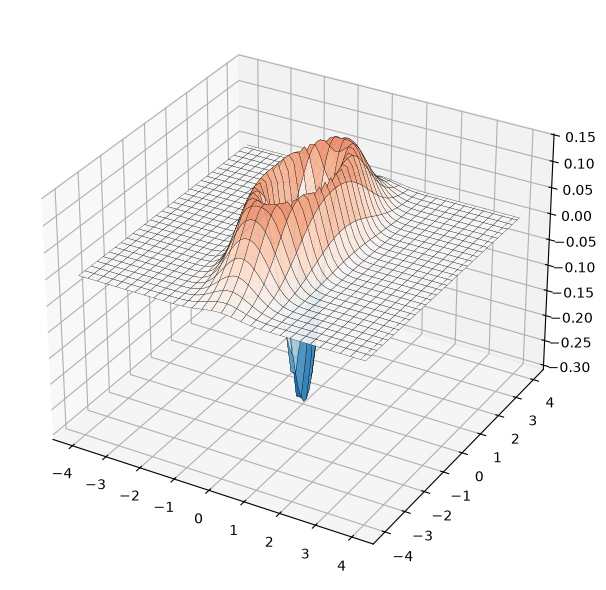

In [63]:
N, r = 25, 0.5
rho, p = pssqv_bs(N, r, 0.99)
print(p,rho)
plot_wigner_3d(rho)

In [ ]:
def pssqv_bs_pnr(N, r, T):
    # compare with ideal b=1
    psi_in = q.tensor(q.squeeze(N, r) * q.basis(N, 0), q.basis(N, 0))
    psi_bs = bs_operator(N, T) * psi_in

    Pi_1 = q.tensor(q.qeye(N), q.basis(N, 1).proj())   #only dif
    rho = Pi_1 * psi_bs.proj() * Pi_1

    rho_out = rho.ptrace(0)
    return rho_out.unit(), rho_out.tr()



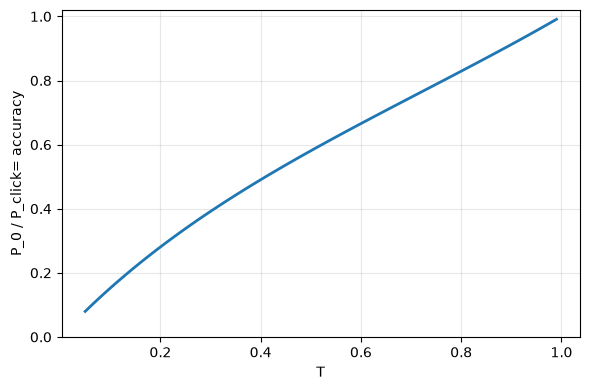

In [71]:
N, r = 25, 0.5
Ts = np.linspace(0.05, 0.99, 60)

p_on  = np.array([pssqv_bs(N, r, T)[1]     for T in Ts])
p_pnr = np.array([pssqv_bs_pnr(N, r, T)[1] for T in Ts])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Ts, p_pnr / p_on, color='C0', lw=2)
ax.set_xlabel('T')
ax.set_ylabel('P_0 / P_click= accuracy')
ax.set_ylim(0, 1.02)
ax.grid(alpha=.3)
plt.tight_layout()

theta high good accuracy

## Simulate homodyne measurements

To characterise the state we generate experimentally, we wish to perform [quantum state tomography](https://en.wikipedia.org/wiki/Quantum_tomography) (QST) based on homodyne detection, which measures the rotated quadrature observable $\hat{x}_\theta = \hat{x}\cos\theta + \hat{p}\sin\theta$. For a tomographic reconstruction of the output state, the same state has to be generated multiple times (QST assumes that we can do identically prepared states). For a range of phase values $\theta$ between 0 and $\pi$, the $\hat{x}_\theta$ quadrature should then be sampled a number of times. This results in histograms of the quadrature distributions at different angles – similar to a [medical tomogram](https://en.wikipedia.org/wiki/Tomography), hence the name. From these "shadows" of the state's Wigner function, the full Wigner function can be reconstructed using various numerical algorithms, each with their own pros and cons. Later, you will use the Maximum Likelihood-based iterative algorithm by [Lvovsky](https://iopscience.iop.org/article/10.1088/1464-4266/6/6/014) to do this reconstruction.

But first, you need to simulate the outcome of the homodyne measurements. You do that by sampling randomly from the marginal quadrature probability distributions $p(x_\theta) = \langle x_\theta| \hat\rho_\text{out} | x_\theta\rangle$. There are two more-or-less good ways to do this, given a density matrix $\rho_{mn}$ in the Fock basis:

**Method 1**: Define a function to calculate the $x_\theta$ basis wavefunction of the Fock states $|n\rangle$, $\langle x_\theta | n\rangle$. This is given in my thesis, eq. (2.6). Now build the marginal distribution over $x_\theta$ (for a reasonable range of $x$ values) from $p(x_\theta) = \langle x_\theta| \hat\rho | x_\theta \rangle = \sum_{mn} \langle x_\theta|m\rangle \rho_{mn} \langle n| x_\theta \rangle$.

**Method 2**: First calculate the Wigner function from the density matrix, using `qutip.wigner` over a reasonable range of x and p values (which you can gauge from a plot of the Wigner function), and then make use of the fact that the marginal $x$ distribution is obtained by integrating the Wigner function over the $p$ variable: $p(x) = \int_{-\infty}^\infty W(x,p) dp$. To get the quadrature distribution over a $x_\theta$ for a $\theta$ different from 0, the easiest way in QuTiP is to first rotate the state by $-\theta$ before building the Wigner distribution over the x$ and $p$ coordinates. This can be done by the phase shift or rotation operator $\hat{R}(\theta) = e^{i\theta\hat{n}}$ which you can easily implement yourself.

NOTE: `qutip.wigner` has an annoying convention where the first dimension of the output array corresponds to p coordinates, while the second dimension is x. You can transpose the output or integrate over the other axis.

### Task 3

* Create one specific 1-PSSQV state that you assume to have experimentally generated.
* Obtain the marginal x-distribution $p(x)$ either by Method 1 or Method 2:
  * Method 1: First calculate all the elements $\langle x | n \rangle$ for a suitable range of $x$ values and all $n$ values up to your cutoff. Then do the sum stated above by matrix products.
  * Method 2: Calculate the Wigner function over a sufficiently fine-meshed and sufficiently wide $(x,p)$ grid using `qutip.wigner`, where the `xvec` and `pvec` arguments determine the grid. Then, numerically integrate over the grid of $W(x,p)$ values. Find a suitable method in `scipy.integrate`.
* Sample $n_\text{samples}$ random $x$ values from this distribution using either [rejection sampling or inversion sampling](https://thenumb.at/Sampling/). The latter is essentially already implemented in the `.rvs` method of the `scipy.stats.rv_histogram` distribution (see [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_histogram.html)). As a simpler alternative, you can just sample values from your pre-determined grid using `choice` from NumPy's `random` module – this can be given the probabilities of each possible value as an argument.
* Now continue with other phases $\theta$. A typical choice of $\theta$ values is an even distribution of a few phases between 0 and $\pi$, e.g. {0°, 30°, 60°, 90°, 120°, 150°}. You can vary this later.
* Plot the obtained distributions. You should see something similar to Fig. 4.21 in my thesis.

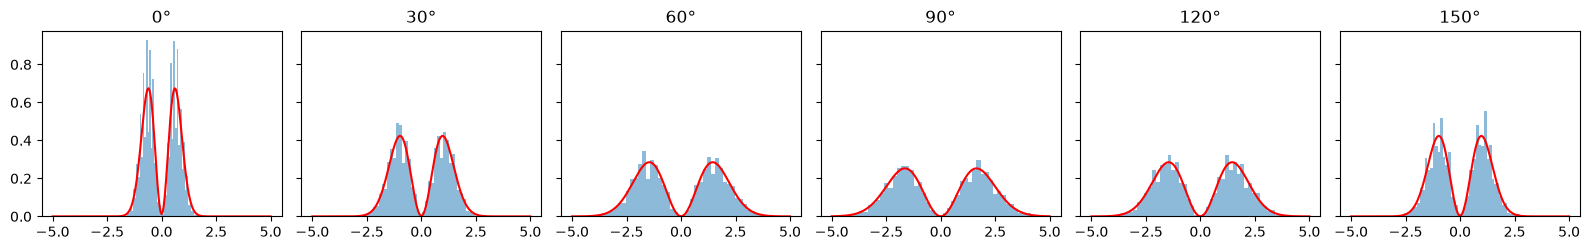

In [ ]:
from scipy.integrate import simpson

# ── Task 2에서 만든 상태 하나 고정
N, r, T = 25, 0.5, 0.99
rho, _ = pssqv_bs(N, r, T)

xvec = np.linspace(-5, 5, 201)


def marginal(rho, theta): # totating mountsin
    """θ 방향 측정의 확률분포 p(x_θ)"""
    R = (1j * theta * q.num(rho.shape[0])).expm()   # 회전 연산자
    W = q.wigner(R * rho * R.dag(), xvec, xvec)     # [p, x] 순서
    return simpson(W, x=xvec, axis=0)               # p축으로 눌러버림


def sample(p, n=5000):
    p = np.clip(p, 0, None)      # 음수 오차 제거
    return np.random.choice(xvec, size=n, p=p / p.sum())

# ── 6개 방향
thetas = np.linspace(0, np.pi, 6, endpoint=False)

fig, axes = plt.subplots(1, 6, figsize=(16, 2.6), sharey=True)
for ax, th in zip(axes, thetas):
    p = marginal(rho, th)
    data = sample(p)
    ax.hist(data, bins=50, density=True, alpha=.5)
    ax.plot(xvec, p, 'r', lw=1.5)
    ax.set_title(f"{np.degrees(th):.0f}°")
plt.tight_layout()

## Do quantum state reconstruction

When you have a histogram containing homodyne measurement samples at different $\theta$ values, $\{x_{\theta,i}\}$ for $i\in\{1,\ldots,n_\text{samples}\}$, whether obtained experimentally or from a simulation like here, it is possible to estimate the underlying (in principle unknown) quantum state, represented by its density matrix in the Fock (number) basis, $\rho_{mn}$.

As mentioned above, a good method is the iterative algorithm based on Maximum Likelihood, described in [Lvovsky](https://iopscience.iop.org/article/10.1088/1464-4266/6/6/014/meta) (arXiv version [here](https://arxiv.org/abs/quant-ph?0311097)). The full algorithm is contained in eqs. (1)—(10). The idea is to find the density matrix  $\hat\rho_0$ that would be most likely to produce the observed samples, i.e. the one maximizing the likelihood defined in eq. (1). 

There's nothing fancy about likelihood: Assume you have a random process that can take two different outcomes 1 and 2, like a coin flip (the outcomes should be i.i.d., independent and identically distributed). Flipping the coin a number of times $n_\text{samples}$ gives you an observation like $\{2,2,1,2,1,...\}$ which can be collated into the two frequencies (number of occurences) $f_1$, $f_2$. If you have a model for the experiment that predicts the probability for each of the two outcomes $\text{pr}_1$ and $\text{pr}_2$, then under this model, the overall probability, or likelihood, of obtaining exactly that observation data is given by $\mathcal{L} = \text{pr}_1^{f_1} \text{pr}_2^{f_2}$. That's what eq. (1) expresses.

In homodyne tomography, you have more than two outcomes. There are a number of different $\theta$ values, and for each of these, you have in principle a continuum of $x$ values. For efficiency of the algorithm, it's a good idea to bin your $x$ data into bins of a width of e.g. 0.1. You then have frequency data $f_{\theta,j}$ where $j$ runs over your $x$-bins.

If you have an estimate of the quantum state's density matrix, $\hat\rho$, you can now calculate the probabilities for observing each of the possible binned outcomes, $\text{pr}_{\theta,j}$, using Lvovsky's eqs. (6—8). From the observed frequencies and the estimate's probabilities, you can calculate the likelihood, just as in the coin example above.

The full algorithm now consists of starting from an initial density matrix guess – you can just take the normalised identity matrix – and doing the iteration in eq. (5) using the definition of the projection operator $\hat\R(\hat\rho)$ in eq. (2). The updated density matrix in each iteration step will asymptotically approach the Maximum Likelihood estimator $\rho_0$, but you will have to stop the iteration at some point. It might be a good idea to monitor the likelihood at each step to get a feel for how close it is to convergence. Alternatively, you could monitor the fidelity between the $k$'th and $(k+1)$'th density matrix, which should converge towards 1.

NOTE: Lvovsky eqs. (6,7) is the same as the $p(x_\theta)$ equation mentioned above under Task 2, Method 1. Note also that Lvovsky eq. (8) is the same as (2.6) in my thesis. However, Lvovsky uses a different normalisation convention for the quadrature operators, as mentioned in his footnote: I use $\hbar=1$, he uses $\hbar=2$. Be sure to be consistent! QuTiP uses the $\hbar=1$ convention by default, but it can be changed, as mentioned e.g. in the docstring for `qutip.wigner`:

> g : float, default: sqrt(2)
> 
>   Scaling factor for `a = 0.5 * g * (x + iy)`, default `g = sqrt(2)`.
>   The value of `g` is related to the value of `hbar` in the commutation
>   relation `[x, y] = i * hbar` via `hbar=2/g^2` giving the default
>   value `hbar=1`.


### Task 4

If you made it this far and still have time left, this is perhaps the most exciting task of this exercise.

* Take your simulated homodyne samples from Task 3 and bin them.
* Create a function to calculate the probability $\text{pr}_{\theta,j}$ for each of your $\theta$ and $x_j$ (bin center) values and for a given density matrix. Use eqs. (2.5, 2.6) from my thesis. This function will be called in each iteration step.
* Also, build the projectors $\hat\Pi_{\theta,j}$ for each of those values. These projectors are fixed and will only be created once.
* Create an initial density matrix estimate $\hat\rho^{0}$.
* Within a `for` loop, calculate the $\hat\R(\hat\rho)$ matrix and the $\text{pr}_{\theta,j}$ vector (or matrix, depending on how you've organised your data structures).
* Update the current density matrix estimate according to Lvovsky eq. (5). Monitor (e.g. by a simple `print` statement) the convergence, as suggested above.
* Finally, take your estimated density matrix, create a `qutip.QObj` object from it (give the matrix as the first argument), and calculate the state's Wigner function. 
* Plot and admire! Or not? Did we really create a kitten state?

### Task 5: stretch goals

If you would like to work further on this project, there are now many parameters you can vary and see how that changes the results: There are the "experimental" parameters like $r$, $T$, loss/efficiency, etc., and there are parameters related to the tomography like number of phases, bins, iterations, etc. There's also the Fock basis cutoff, and the possible choice of discretization in the generation of homodyne data points.

## Submit your work

At the end of today, you should submit your notebook (or script) on the [#kitten-tomography](https://discord.com/channels/1527267313563205773/1537003725812662402) channel, even if unfinished. Include a short text of your experience, e.g. something you found particularly challenging or interesting. I will make an effort to give feedback on all the submissions by the beginning of next week (but no promise – I have somewhat limited time available).